# Brazil E-Commerce — Orders Analysis

Analysis of the **Olist `olist_orders_dataset.csv`** file.

Columns:
- `order_id` — unique order identifier
- `customer_id` — key to the customers dataset (one per order)
- `order_status` — delivered / shipped / canceled / etc.
- `order_purchase_timestamp` — when the order was placed
- `order_approved_at` — payment approval time
- `order_delivered_carrier_date` — handed to the logistics partner
- `order_delivered_customer_date` — actual delivery to the customer
- `order_estimated_delivery_date` — promised delivery date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
orders = pd.read_csv("Data/olist_orders_dataset.csv", parse_dates=date_cols)
print(f"Shape: {orders.shape[0]:,} rows x {orders.shape[1]} columns")
orders.head()

Shape: 99,441 rows x 8 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [3]:
orders.info()
orders.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(orders.isna().sum())

dup = orders.duplicated().sum()
print(f"\nFully duplicated rows: {dup:,}")
print(f"Duplicated order_id: {orders['order_id'].duplicated().sum():,}")
print(f"Duplicated customer_id: {orders['customer_id'].duplicated().sum():,} (one order per customer_id)")

Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Fully duplicated rows: 0
Duplicated order_id: 0
Duplicated customer_id: 0 (one order per customer_id)


## 3. Order status breakdown

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


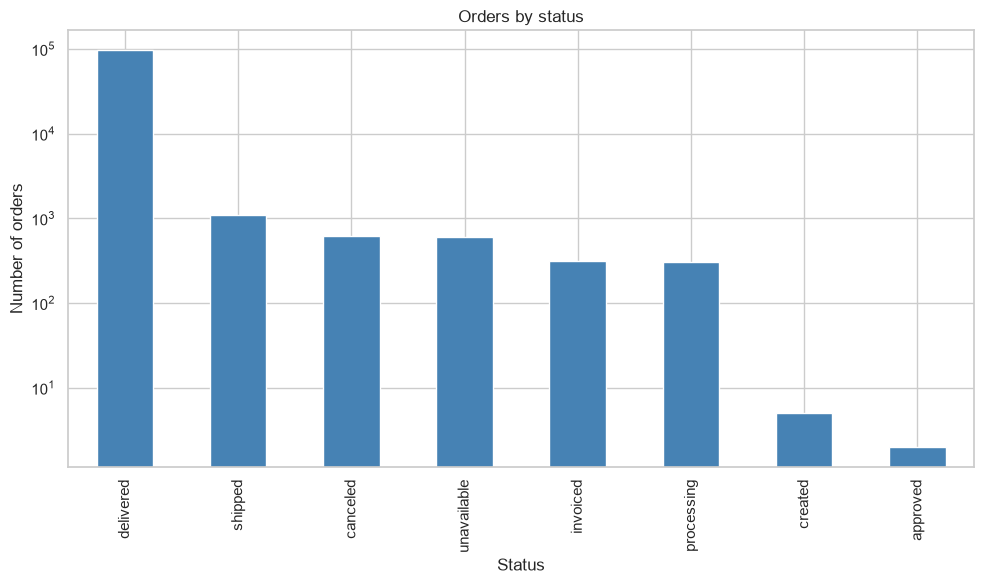

In [5]:
status = orders["order_status"].value_counts()
print(status)

ax = status.plot(kind="bar", color="steelblue")
ax.set_title("Orders by status")
ax.set_xlabel("Status")
ax.set_ylabel("Number of orders")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Orders over time

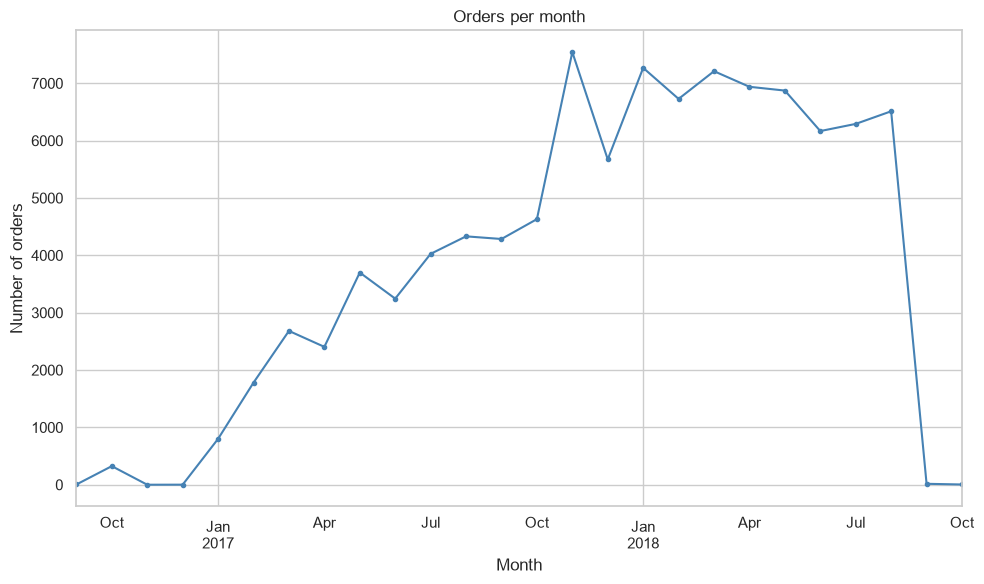

In [6]:
monthly = (
    orders.set_index("order_purchase_timestamp")
    .resample("MS")["order_id"]
    .count()
)
ax = monthly.plot(color="steelblue", marker="o", ms=3)
ax.set_title("Orders per month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of orders")
plt.tight_layout()
plt.show()

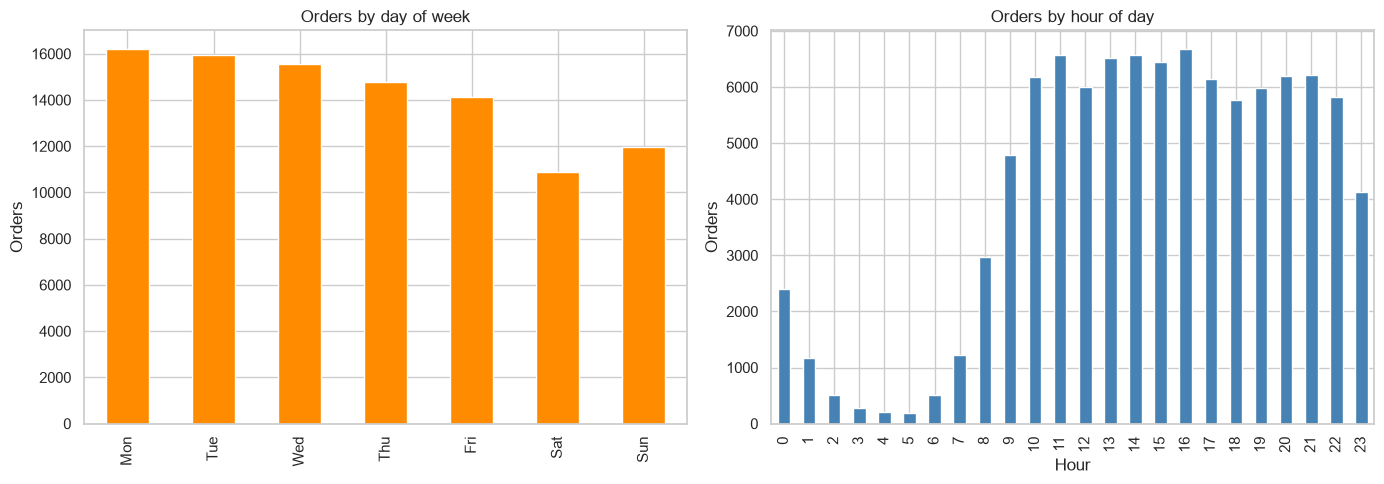

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_dow = orders["order_purchase_timestamp"].dt.dayofweek.value_counts().sort_index()
by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow.plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Orders by day of week")
axes[0].set_ylabel("Orders")

by_hour = orders["order_purchase_timestamp"].dt.hour.value_counts().sort_index()
by_hour.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Orders by hour of day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

## 5. Delivery performance

Compare actual delivery time against the purchase date, and on-time vs. the estimated date.

In [8]:
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.total_seconds() / 86400
delivered["estimate_error_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

late = (delivered["estimate_error_days"] > 0).mean()
print(f"Median delivery time: {delivered['delivery_days'].median():.1f} days")
print(f"Mean delivery time:   {delivered['delivery_days'].mean():.1f} days")
print(f"Orders delivered late (after estimate): {late:.1%}")

Median delivery time: 10.2 days
Mean delivery time:   12.6 days
Orders delivered late (after estimate): 8.1%


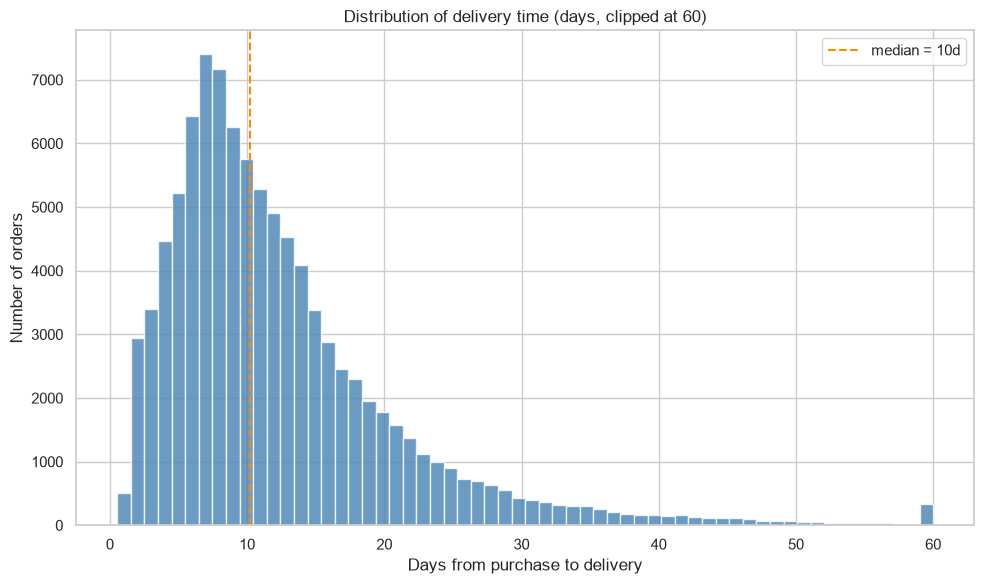

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(delivered["delivery_days"].clip(0, 60), bins=60, color="steelblue", alpha=0.8)
ax.axvline(delivered["delivery_days"].median(), color="darkorange",
           linestyle="--", label=f"median = {delivered['delivery_days'].median():.0f}d")
ax.set_title("Distribution of delivery time (days, clipped at 60)")
ax.set_xlabel("Days from purchase to delivery")
ax.set_ylabel("Number of orders")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- The overwhelming majority of orders reach `delivered` status; cancellations are rare.
- Order volume grows through 2017 and plateaus in 2018; weekday afternoons/evenings dominate.
- Median delivery is ~1–2 weeks and most orders arrive before the (conservative) estimated date.